# Wholesale 고객 분석 통합 노트북 (블로그용)

블로그 포스팅 **"UCI Wholesale 고객 데이터로 보는 고객 세분화 & 채널 예측 대시보드"**에 사용할  
**지표·시각화**를 한 번에 재현하는 노트북입니다.

## 구성 (블로그 목차와 동일)

1. **프로젝트 개요** — 배경, 목표, 사용 기술  
2. **데이터 탐색 및 전처리** — KPI, 상품별 분포, 지역/채널 비율  
3. **머신러닝 프로세스** — K-Means & PCA, 분류 모델(Classification), SHAP 분석  
4. **TabPy 연동 및 태블로 대시보드 제작**  
5. **결과 해석 및 비즈니스 제언**

- **데이터**: hossam 또는 `wholesale_for_tableau.csv` (Channel, Region, 6개 구매액)
- **군집**: 전처리(로그+스케일) → **PCA(설명력 80%)** → **PCA 점수 위에서** K-means(5개 군집)
- **분류**: Logistic Regression 등, 성능 지표·ROC·Feature Importance·SHAP

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, silhouette_score
)

# 한글 폰트 (없으면 기본 폰트)
plt.rcParams['axes.unicode_minus'] = False
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
except Exception:
    pass

LAB05_DIR = Path('.').resolve()
RAW_COLS = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

## 2. 데이터 탐색 및 전처리

### 2.1 데이터 로드

hossam 또는 `wholesale_for_tableau.csv`에서 Channel, Region, 6개 구매액을 불러옵니다.  
(ClusterID, PC1~PC3는 아래에서 재계산합니다.)

In [2]:
def load_wholesale_data():
    """hossam 또는 wholesale_for_tableau.csv에서 데이터 로드. Channel, Region, 6개 구매액 반환."""
    try:
        from hossam import load_data
        origin = load_data('wholesale_customers')
        return origin[['Channel', 'Region'] + RAW_COLS].copy()
    except Exception:
        pass
    csv_path = LAB05_DIR / "wholesale_for_tableau.csv"
    if csv_path.exists():
        df_full = pd.read_csv(csv_path, encoding='utf-8-sig')
        return df_full[['Channel', 'Region'] + RAW_COLS].copy()
    raise FileNotFoundError(
        "데이터를 찾을 수 없습니다. create_tableau_csv.py를 실행하거나 "
        "hossam 패키지로 'wholesale_customers'를 사용 가능하게 해주세요."
    )

df = load_wholesale_data()
df.info()
df.head(10)

c:\Users\bohee\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.4.8
이 데이터 세트는 도매 유통업체의 고객 정보를 담고 있습니다. 다양한 제품 카테고리에 대한 연간 지출액(mu, 화폐 단위)을 포함합니다. (출처: https://www.kaggle.com/datasets/binovi/wholesale-customers-data-set)

컬럼명            의미                  설명
----------------  --------------------  --------------------------------------------------------------------------------------------
Channel           유통 채널             고객의 거래 채널을 나타냄. 주로 Horeca(호텔·레스토랑·카페) 또는 Retail(소매점) 구분에 사용됨
Region            지역                  고객이 속한 지리적 지역 구분 변수. 특정 국가 내의 권역 정보
Fresh             신선식품 구매액       육류, 채소, 과일 등 신선식품 카테고리에 대한 연간 구매 금액
Milk              유제품 구매액         우유, 치즈, 요거트 등 유제품 카테고리에 대한 연간 구매 금액
Grocery           식료품 구매액         가공식품, 일반 식료품 등 장기 보관 식품 카테고리 구매 금액
Frozen            냉동식품 구매액       냉동 육류, 냉동 가공식품 등 냉동식품 카테고리 구매 금액
Detergents_Paper  세제·종이

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
5,2,3,9413,8259,5126,666,1795,1451
6,2,3,12126,3199,6975,480,3140,545
7,2,3,7579,4956,9426,1669,3321,2566
8,1,3,5963,3648,6192,425,1716,750
9,2,3,6006,11093,18881,1159,7425,2098


### 2.2 결측치 현황 및 분포 특성(왜도)

결측치를 확인하고, 품목별 구매액의 **왜도(Skewness)**를 계산합니다.  
왜도 > 0이면 우측 꼬리가 긴 분포로, 로그 변환이 필요한 근거가 됩니다.

In [ ]:
# 결측치 현황 (블로그: 결측치 0건 근거)
null_counts = df.isnull().sum()
print("=== 결측치 현황 ===")
print(null_counts.to_string())
print(f"\n총 결측: {null_counts.sum()}건 → 결측 처리 없이 분석 진행")

# 품목별 왜도(Skewness) — 우측 꼬리 분포 확인
skew_raw = df[RAW_COLS].skew()
print("\n=== 품목별 왜도 (원본 구매액) ===")
print(skew_raw.round(4).to_string())
print("  (왜도 > 0: 우측 꼬리, 로그 변환으로 완화 대상)")

### 2.3 기술통계 & 비즈니스 KPI (블로그 [수치] 대입용)

In [3]:
# 기술통계
display(df.describe())

# 비즈니스 KPI (블로그/대시보드용)
총_구매금액 = df[RAW_COLS].sum().sum()
고객수 = len(df)
고객당_평균_구매액 = df[RAW_COLS].sum(axis=1).mean()
품목별_매출 = df[RAW_COLS].sum()
품목별_매출_비중 = (품목별_매출 / 총_구매금액 * 100).round(1)
print(f"\n[비즈니스 KPI]")
print(f"  연간 전체 구매금액 합계: {총_구매금액:,.0f}")
print(f"  총 거래 고객 수: {고객수}")
print(f"  고객당 평균 연간 구매액(ARPU): {고객당_평균_구매액:,.0f}")
print(f"  품목별 매출 비중(%): {품목별_매출_비중.to_dict()}")

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000



[비즈니스 KPI]
  연간 전체 구매금액 합계: 14,619,500
  총 거래 고객 수: 440
  고객당 평균 연간 구매액: 33,226


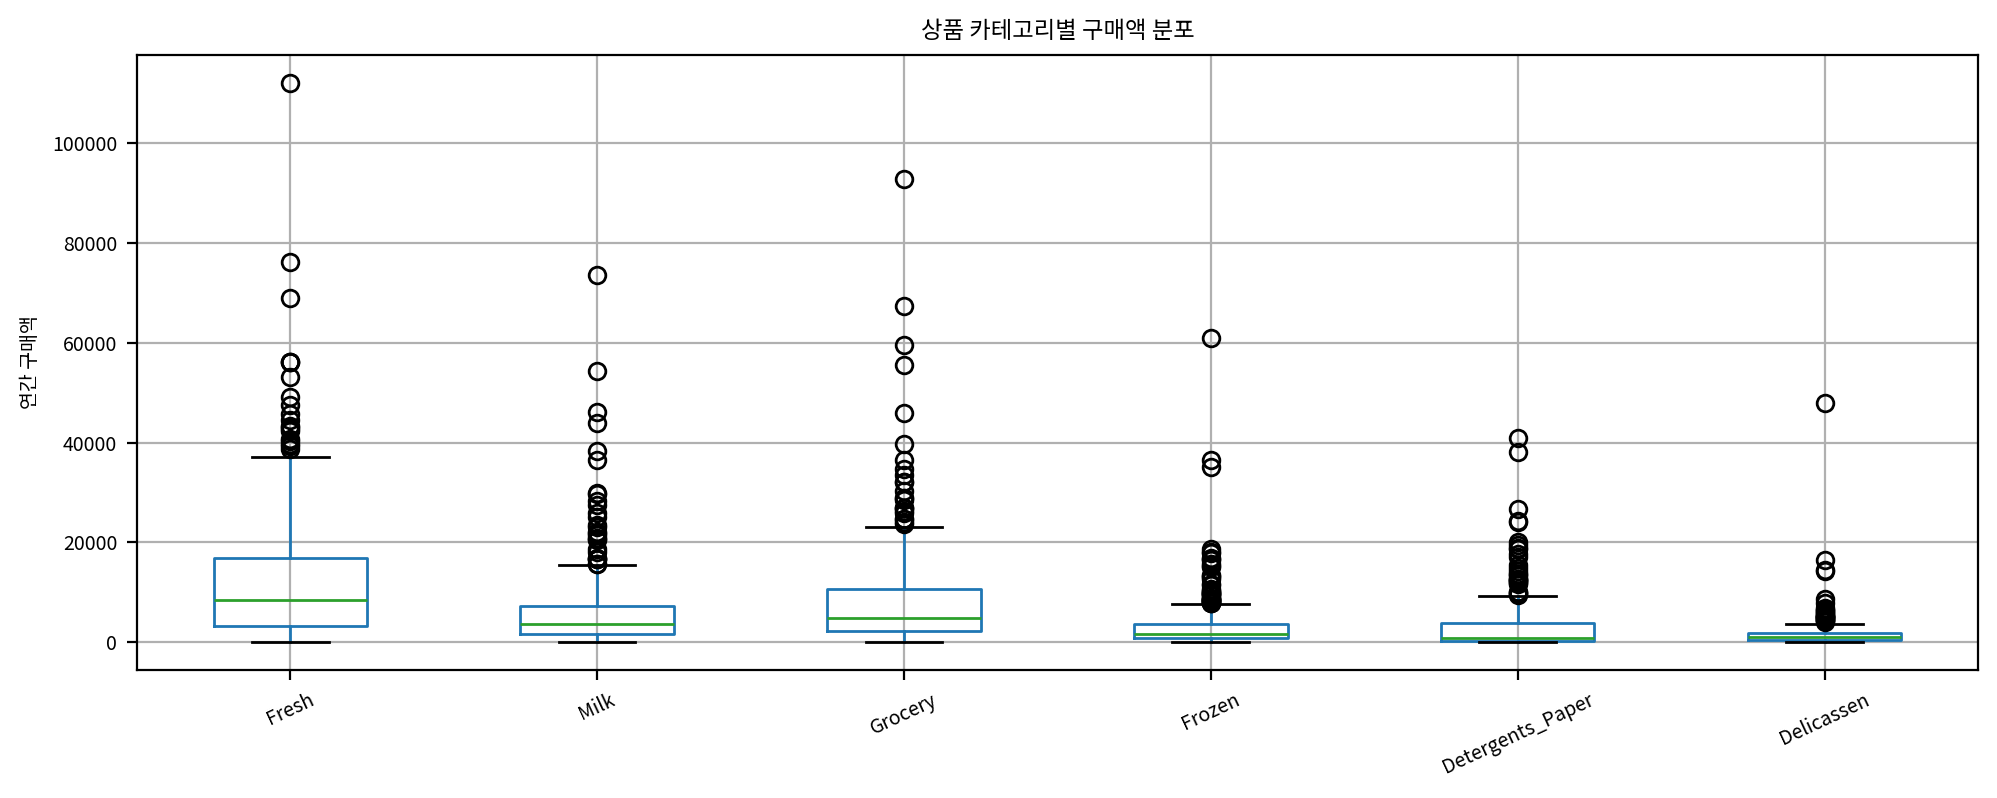

In [4]:
# 상품별 매출 분포 (박스 플롯)
fig, ax = plt.subplots(figsize=(10, 4))
df[RAW_COLS].boxplot(ax=ax)
ax.set_ylabel('연간 구매액')
ax.set_title('상품 카테고리별 구매액 분포')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

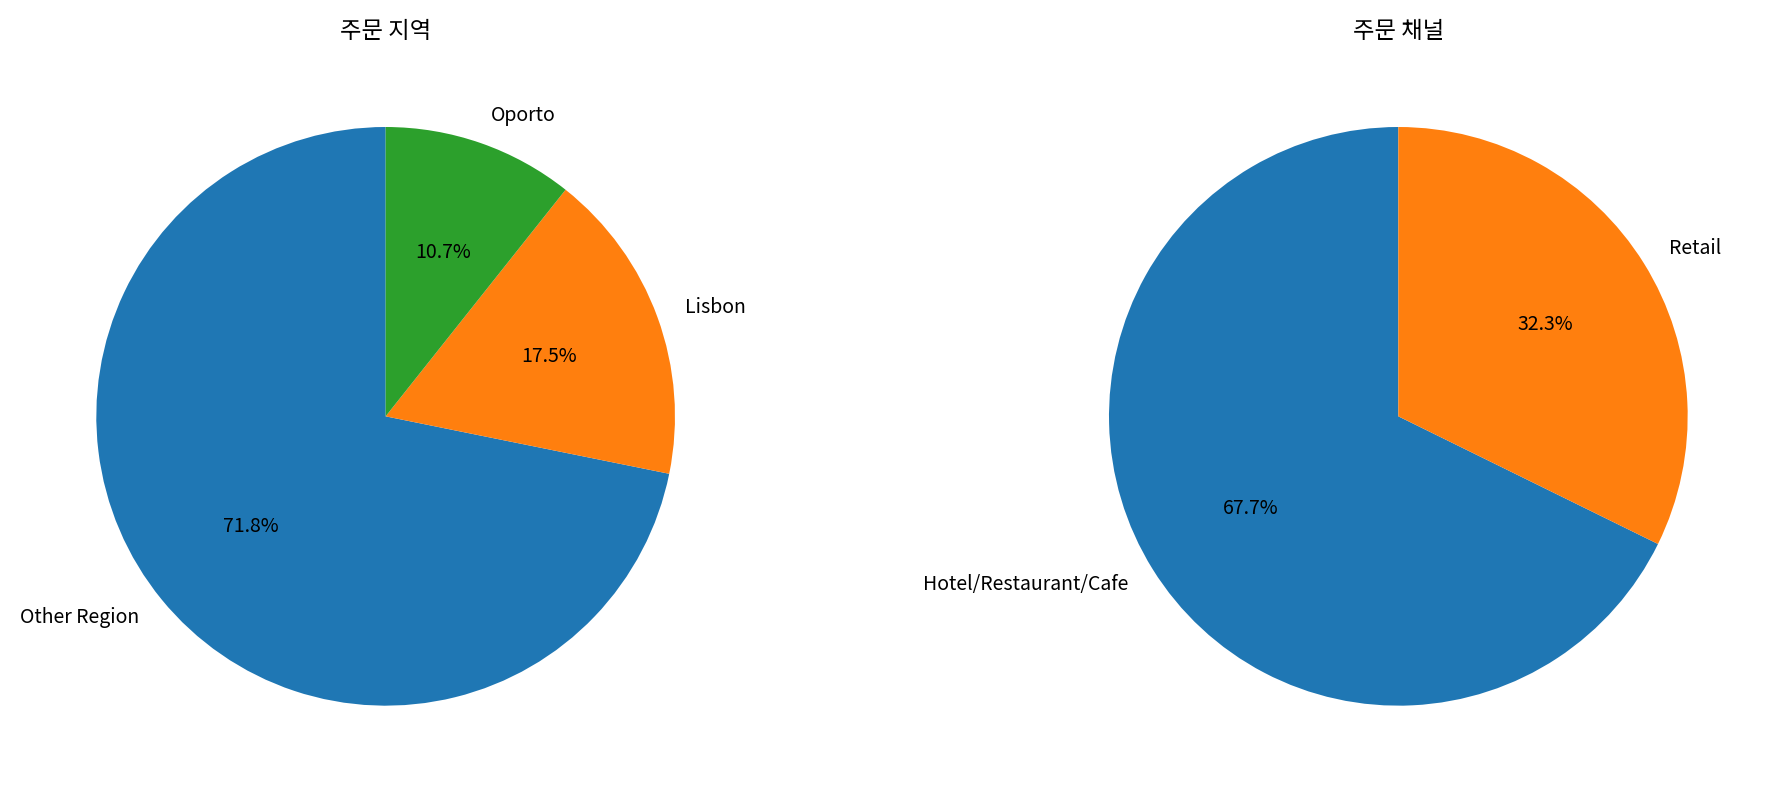

In [5]:
# 주문 지역 / 주문 채널 비율 (파이 차트)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
region_counts = df['Region'].map({1: 'Lisbon', 2: 'Oporto', 3: 'Other Region'}).value_counts()
channel_counts = df['Channel'].map({1: 'Hotel/Restaurant/Cafe', 2: 'Retail'}).value_counts()
ax1.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('주문 지역')
ax2.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('주문 채널')
plt.tight_layout()
plt.show()

## 3. 머신러닝 프로세스

### 3.1 K-Means 클러스터링 & PCA

**파이프라인**: 6개 구매액 로그 변환 → StandardScaler → PCA(설명력 80%) → **PCA 점수(주성분 좌표) 위에서** K-means(5개 군집).  
원본 변수가 아닌 PCA 공간에서 군집화하여 해석을 쉽게 하고 군집 품질을 안정화했습니다.

In [6]:
# 전처리: 로그 + 스케일
df_log = df[RAW_COLS].copy()
for c in RAW_COLS:
    df_log[f'log_{c}'] = np.log1p(df_log[c])
log_cols = [f'log_{c}' for c in RAW_COLS]
scaler = StandardScaler()
sdf_log = pd.DataFrame(scaler.fit_transform(df_log), columns=df_log.columns)[log_cols]

# PCA (설명력 80%)
pca = PCA(n_components=0.8, random_state=52)
pca_scores = pca.fit_transform(sdf_log)
n_components = pca_scores.shape[1]
print(f"PCA 주성분 수: {n_components}, 설명 분산 비율: {pca.explained_variance_ratio_.round(3)}")

# K-means on PCA scores
kmeans = KMeans(n_clusters=5, random_state=52)
clusters = kmeans.fit_predict(pca_scores)
df['ClusterID'] = clusters

# 군집별 고객 수
print("\n군집별 고객 수:")
print(df['ClusterID'].value_counts().sort_index())
print(f"\n실루엣 스코어: {silhouette_score(pca_scores, clusters):.4f}")

PCA 주성분 수: 3, 설명 분산 비율: [0.441 0.272 0.107]

군집별 고객 수:
ClusterID
0    114
1    108
2    124
3     53
4     41
Name: count, dtype: int64

실루엣 스코어: 0.2689


In [ ]:
# 전처리 효과 요약 (블로그: 로그 변환·StandardScaler 근거)
# 로그 변환 후 왜도 감소 확인
skew_log = df_log[log_cols].skew()
print("=== 로그 변환 후 품목별 왜도 ===")
print(skew_log.round(4).to_string())
print("  → 원본 대비 왜도 감소로 분포가 완만해짐")

# StandardScaler 적용 후 평균·표준편차 (모두 동일 스케일)
print("\n=== StandardScaler 적용 후 (평균≈0, 표준편차≈1) ===")
print(sdf_log.agg(["mean", "std"]).round(6).to_string())

In [7]:
# 군집별 평균 구매액 & 전체 대비 비율 (페르소나 해석용)
cluster_mean = df.groupby('ClusterID')[RAW_COLS].mean().round(0)
total_mean = df[RAW_COLS].mean()
cluster_ratio = (cluster_mean / total_mean).round(2)
print("군집별 평균 구매액 (원본 스케일):")
display(cluster_mean)
print("군집별 - 전체 대비 비율 (1 = 평균과 동일):")
display(cluster_ratio)

군집별 평균 구매액 (원본 스케일):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
ClusterID,,,,,,
0,8393.0,3000.0,3584.0,1416.0,908.0,598.0
1,13054.0,12578.0,16236.0,3096.0,6571.0,3022.0
2,19612.0,3233.0,3642.0,5732.0,544.0,1678.0
3,2131.0,7979.0,15724.0,405.0,7189.0,939.0
4,8993.0,637.0,1257.0,3017.0,149.0,454.0


군집별 - 전체 대비 비율 (1 = 평균과 동일):


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
ClusterID,,,,,,
0,0.70,0.52,0.45,0.46,0.32,0.39
1,1.09,2.17,2.04,1.01,2.28,1.98
2,1.63,0.56,0.46,1.87,0.19,1.10
3,0.18,1.38,1.98,0.13,2.49,0.62
4,0.75,0.11,0.16,0.98,0.05,0.30


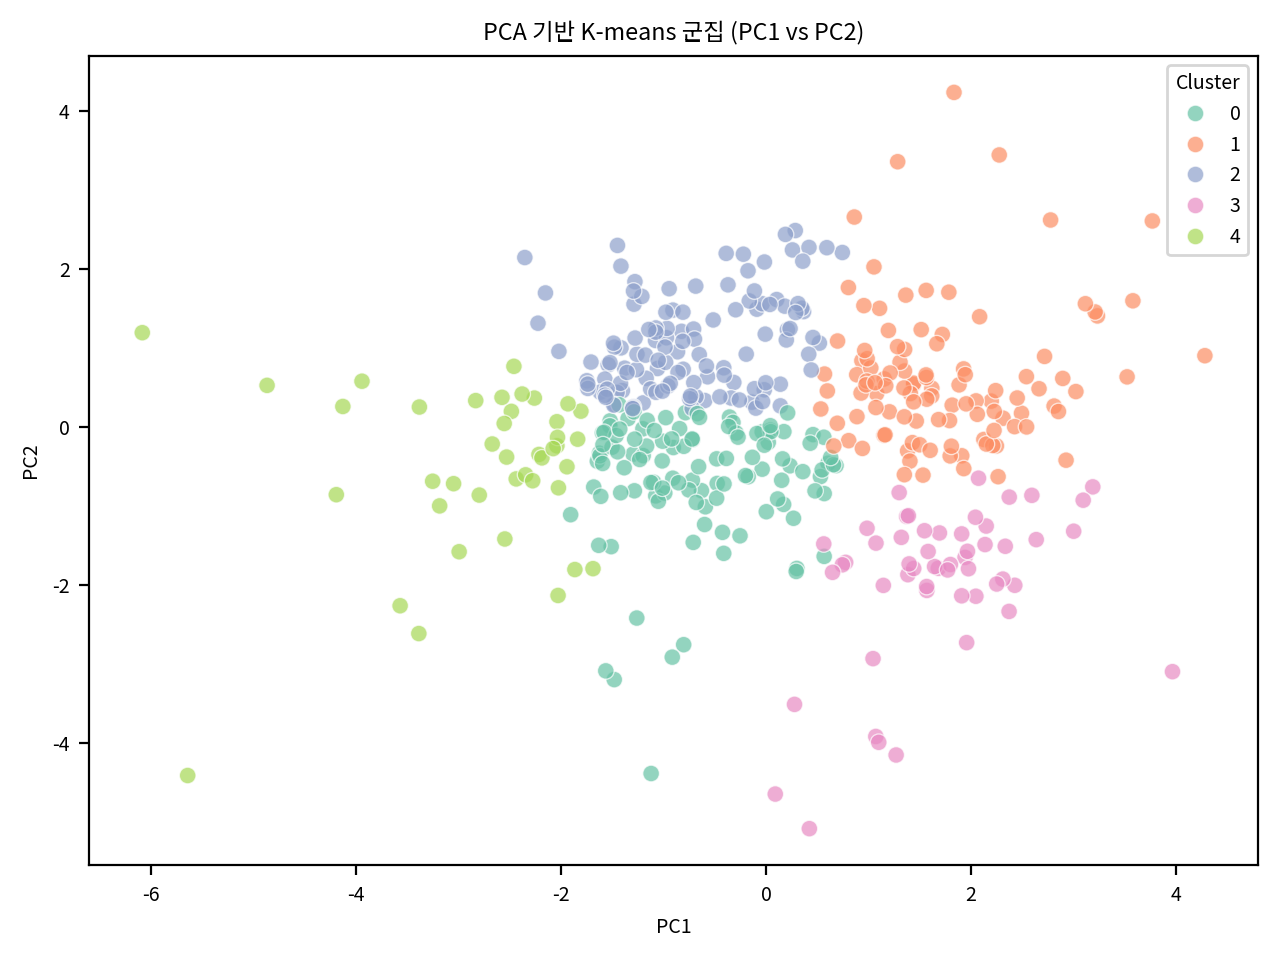

In [8]:
# PCA 스코어 PC1-PC2 산점도 (군집별 색상)
df_plot = df.copy()
df_plot['PC1'] = pca_scores[:, 0]
df_plot['PC2'] = pca_scores[:, 1]
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='ClusterID', palette='Set2', alpha=0.7)
plt.title('PCA 기반 K-means 군집 (PC1 vs PC2)')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### 3.2 머신러닝 분류 모델 (Classification)

- **타겟**: Channel 1(호레카) → 0, 2(소매) → 1  
- **피처**: 로그 스케일 6개 + Region 원핫(Region_2, Region_3) = 8개  

아래는 대표 모델인 **Logistic Regression** 기준 학습·평가입니다. 여러 모델 비교는 다음 셀(선택)을 참고하세요.

In [9]:
# 분류용 전처리: 로그 6 + Region 더미
df_clf = df[RAW_COLS + ['Region', 'Channel']].copy()
for c in RAW_COLS:
    df_clf[f'log_{c}'] = np.log1p(df_clf[c])
region_dum = pd.get_dummies(df_clf['Region'], prefix='Region', drop_first=True)
X_df = pd.concat([df_clf[log_cols], region_dum], axis=1)
feature_cols = list(X_df.columns)
X = StandardScaler().fit_transform(X_df)
y = (df_clf['Channel'] - 1).values  # 1→0, 2→1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=52, stratify=y
)
print("Train:", X_train.shape, "Test:", X_test.shape, "Features:", feature_cols)

Train: (330, 8) Test: (110, 8) Features: ['log_Fresh', 'log_Milk', 'log_Grocery', 'log_Frozen', 'log_Detergents_Paper', 'log_Delicassen', 'Region_2', 'Region_3']


In [10]:
# Logistic Regression 학습 및 평가
clf = LogisticRegression(max_iter=1000, random_state=52)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
pr = precision_score(y_test, y_pred, zero_division=0)
re = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print("[Logistic Regression 성능 지표]")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {pr:.4f}")
print(f"  Recall:   {re:.4f}")
print(f"  F1:       {f1:.4f}")
print(f"  AUC:      {auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

[Logistic Regression 성능 지표]
  Accuracy:  0.9091
  Precision: 0.9032
  Recall:   0.8000
  F1:       0.8485
  AUC:      0.9512

Confusion Matrix:
[[72  3]
 [ 7 28]]


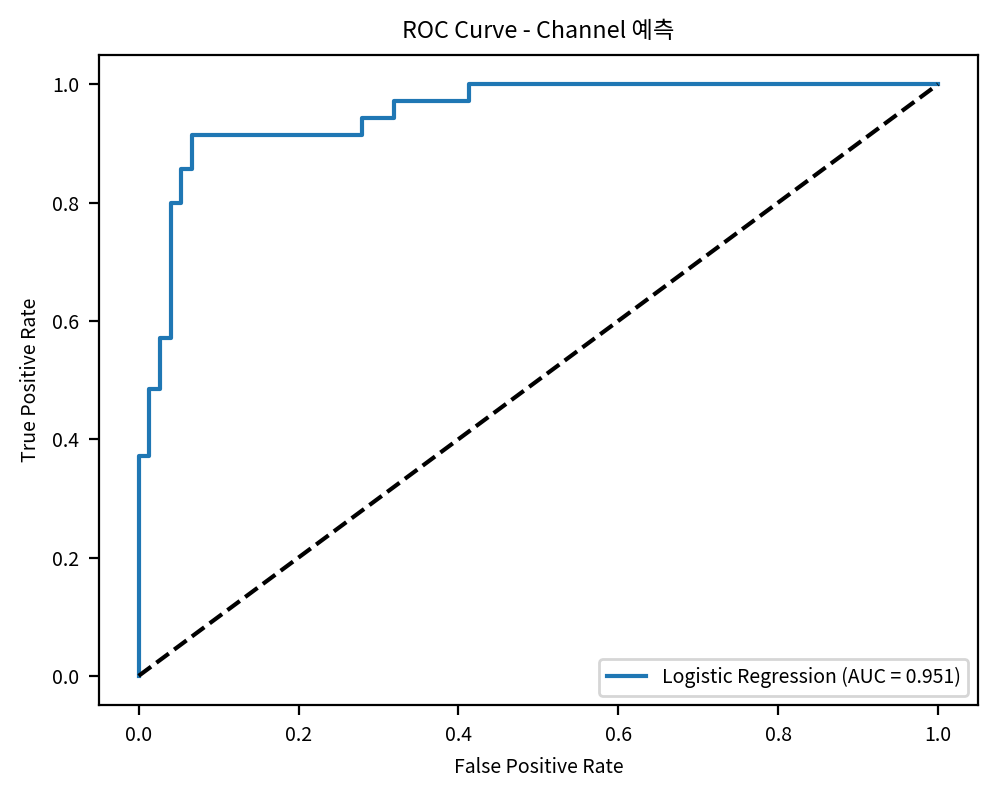

In [11]:
# ROC 곡선
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Channel 예측')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# [선택] 여러 분류 모델 성능 비교 (pkl이 있을 때만) — 블로그 [표1] 참고
import pickle
MODELS_PKL = [
    ("LogisticRegression", "wholesale_logistic.pkl"),
    ("XGBoost", "wholesale_xgb.pkl"),
    ("RandomForest", "wholesale_rf.pkl"),
    ("SGDClassifier", "wholesale_sgd.pkl"),
]
rows = []
for name, pkl_name in MODELS_PKL:
    path = LAB05_DIR / pkl_name
    if not path.exists():
        continue
    with open(path, "rb") as f:
        clf = pickle.load(f)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, 'predict_proba') else y_pred
    rows.append({
        "모델": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "AUC": round(roc_auc_score(y_test, y_proba), 4) if len(np.unique(y_test)) > 1 else 0,
    })
if rows:
    perf_df = pd.DataFrame(rows)
    display(perf_df)
else:
    print("pkl 파일이 없어 모델 비교를 건너뜁니다. (02~05 노트북에서 각각 저장 후 다시 실행)")

,모델,Accuracy,Precision,Recall,F1,AUC
0,LogisticRegression,0.9000,0.9000,0.7714,0.8308,0.9547
1,XGBoost,0.8909,0.9259,0.7143,0.8065,0.9349
2,RandomForest,0.9000,0.9000,0.7714,0.8308,0.9463
3,SGDClassifier,0.9091,0.8571,0.8571,0.8571,0.9341


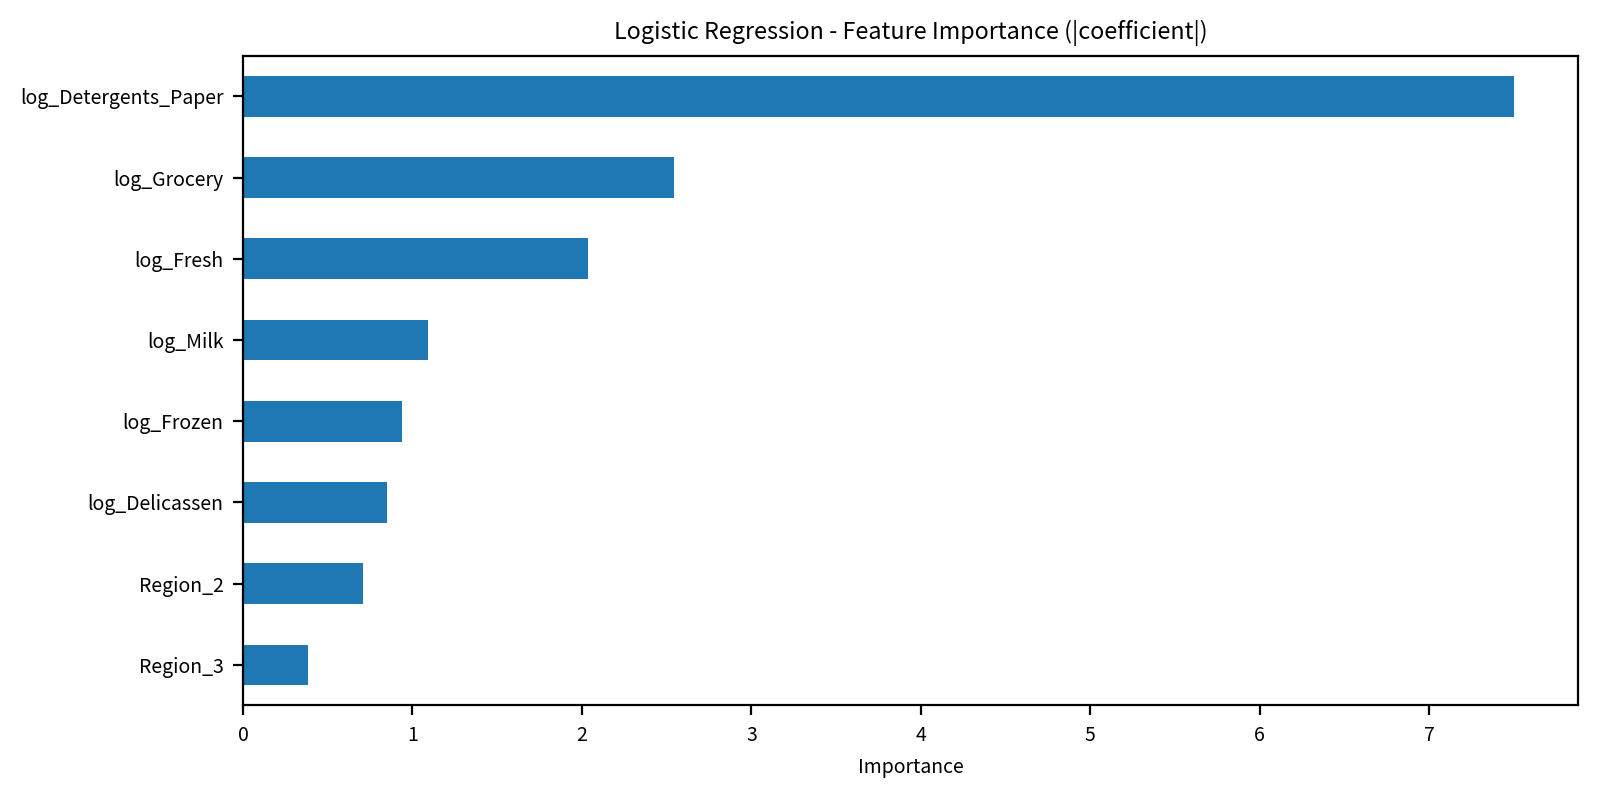

In [13]:
# Feature Importance (계수 절댓값)
imp = np.abs(clf.coef_[0])
fi = pd.Series(imp, index=feature_cols).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(8, 4))
plt.title('Logistic Regression - Feature Importance (|coefficient|)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 3.3 SHAP 분석

채널 예측에 각 변수가 얼마나 기여하는지 개별 예측 수준에서 설명합니다.

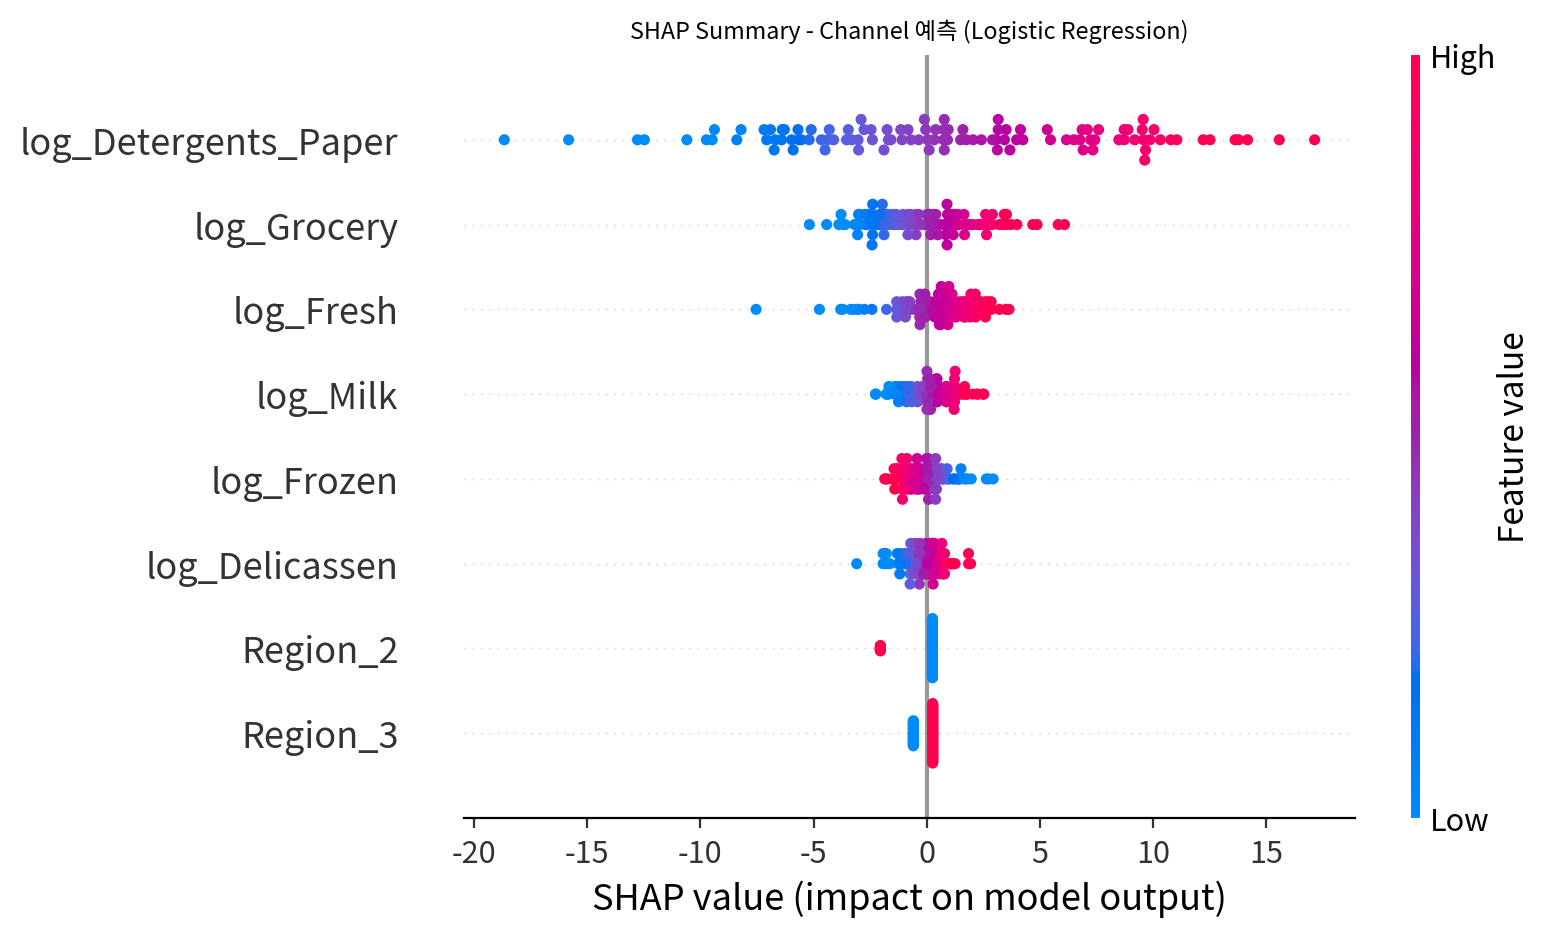

In [14]:
import shap

# SHAP (LinearExplainer for Logistic Regression)
explainer = shap.LinearExplainer(clf, X_train)
sv = explainer.shap_values(X_test)
# 이진 분류 시 리스트로 오면 양성(1) 클래스 사용
shap_values = sv[1] if isinstance(sv, list) and len(sv) == 2 else sv

# 요약 시각화: 특성별 SHAP 영향 (테스트 세트)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols, show=False)
plt.title('SHAP Summary - Channel 예측 (Logistic Regression)')
plt.tight_layout()
plt.show()

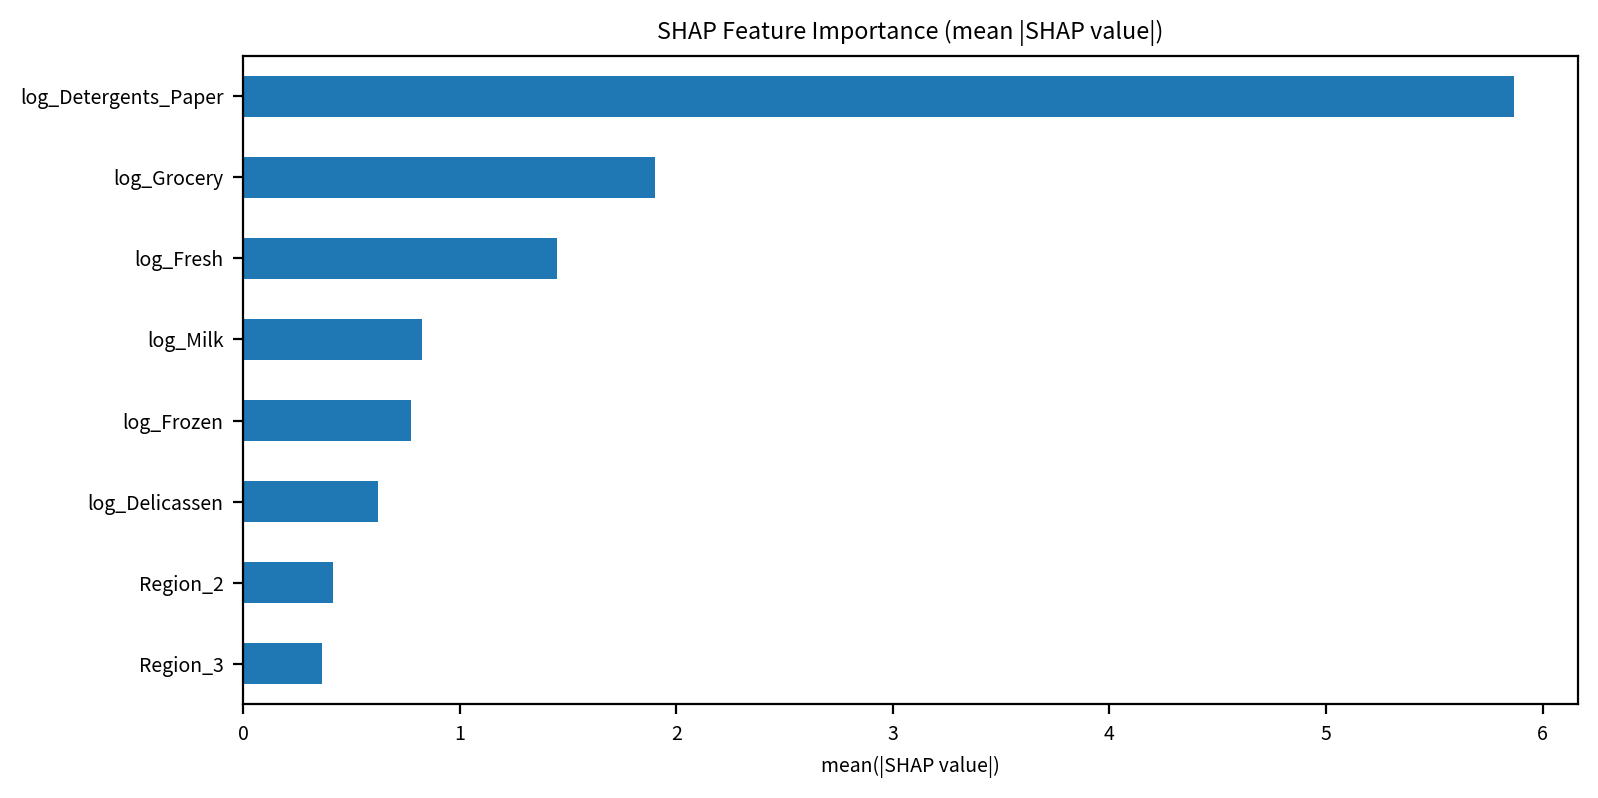

In [15]:
# SHAP 절댓값 평균 (특성 중요도 대체)
shap_importance = np.abs(shap_values).mean(axis=0)
shap_imp_series = pd.Series(shap_importance, index=feature_cols).sort_values(ascending=True)
shap_imp_series.plot(kind='barh', figsize=(8, 4))
plt.title('SHAP Feature Importance (mean |SHAP value|)')
plt.xlabel('mean(|SHAP value|)')
plt.tight_layout()
plt.show()

### 블로그용 그림 저장 (선택)

아래 셀을 실행하면 `blog_figures/` 폴더에 블로그 포스팅에 넣을 수 있는 이미지가 저장됩니다.  
(이미 위에서 그린 figure를 재사용해 저장합니다.)

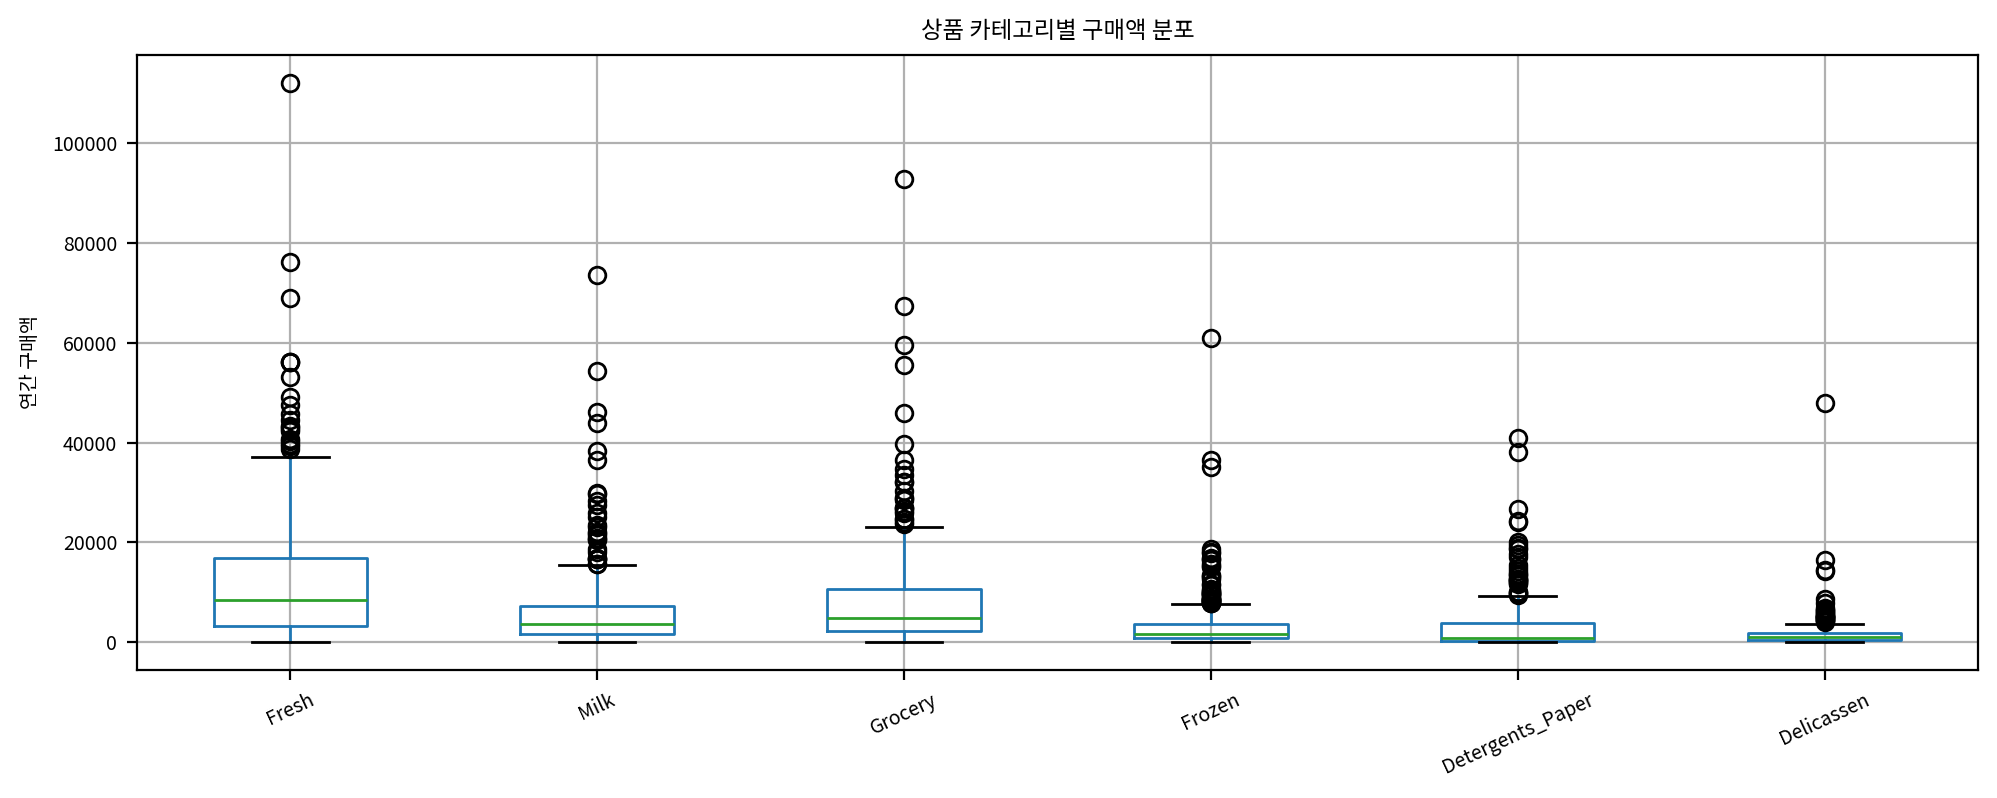

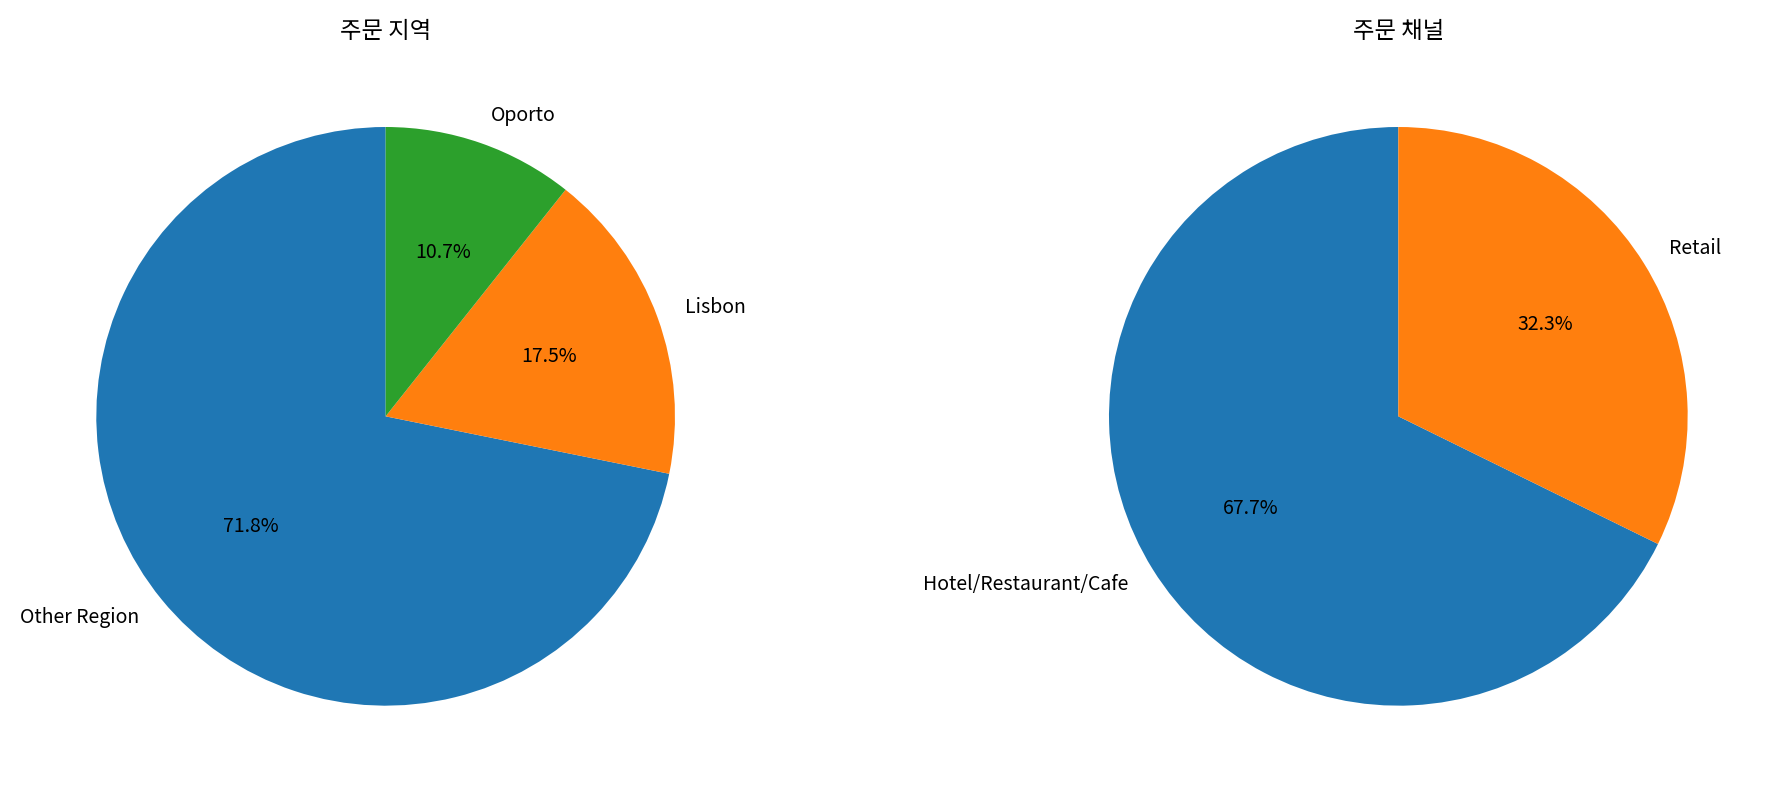

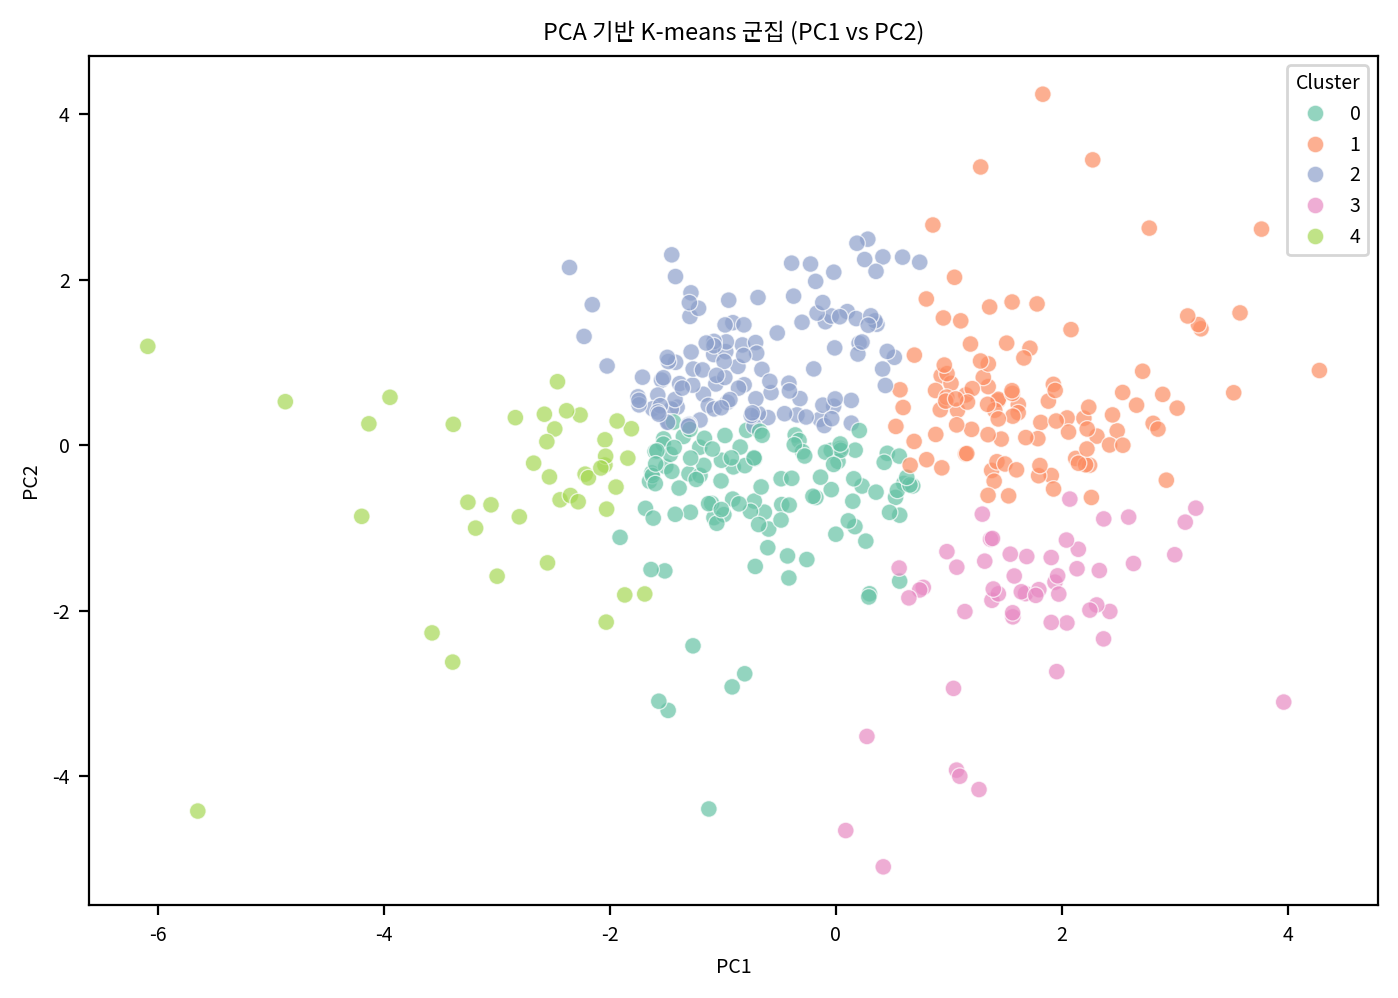

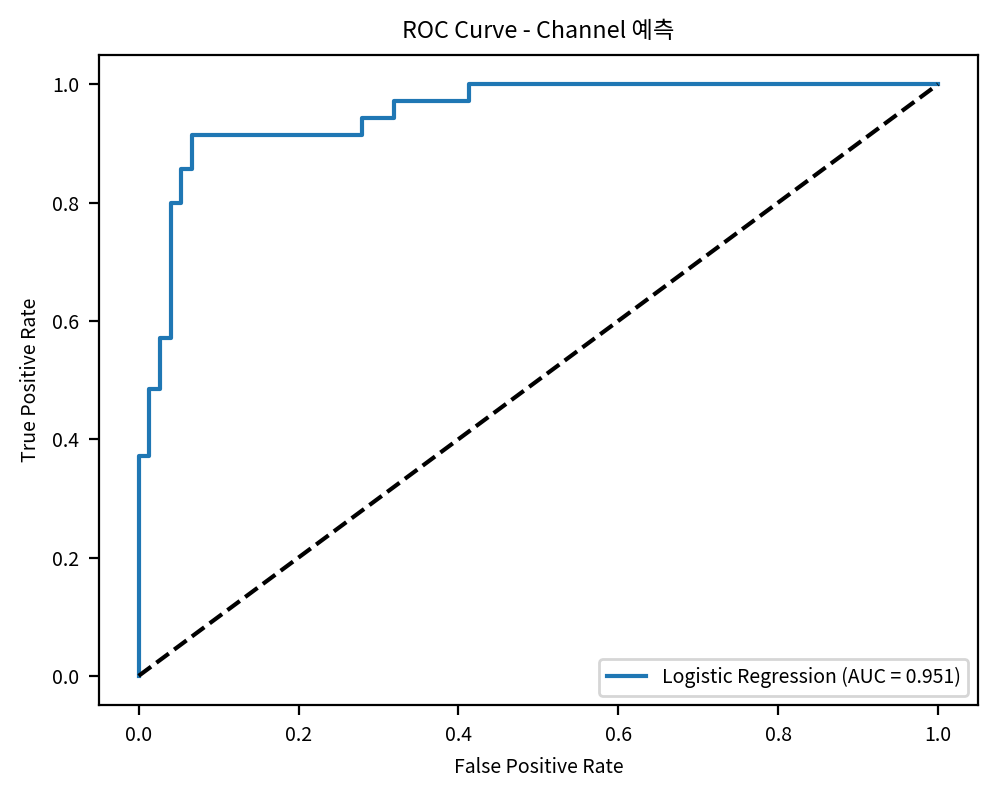

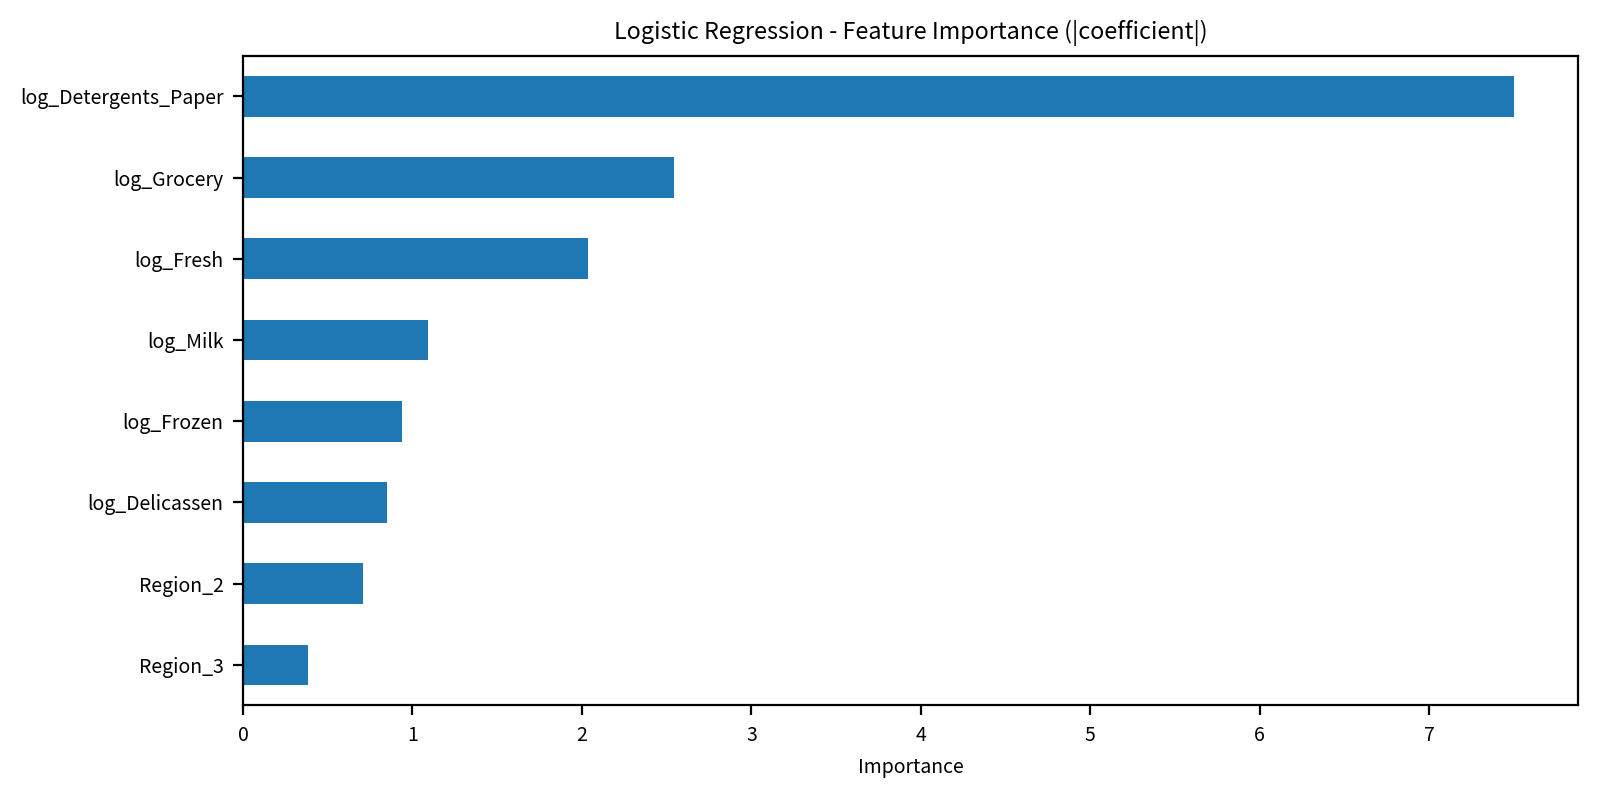

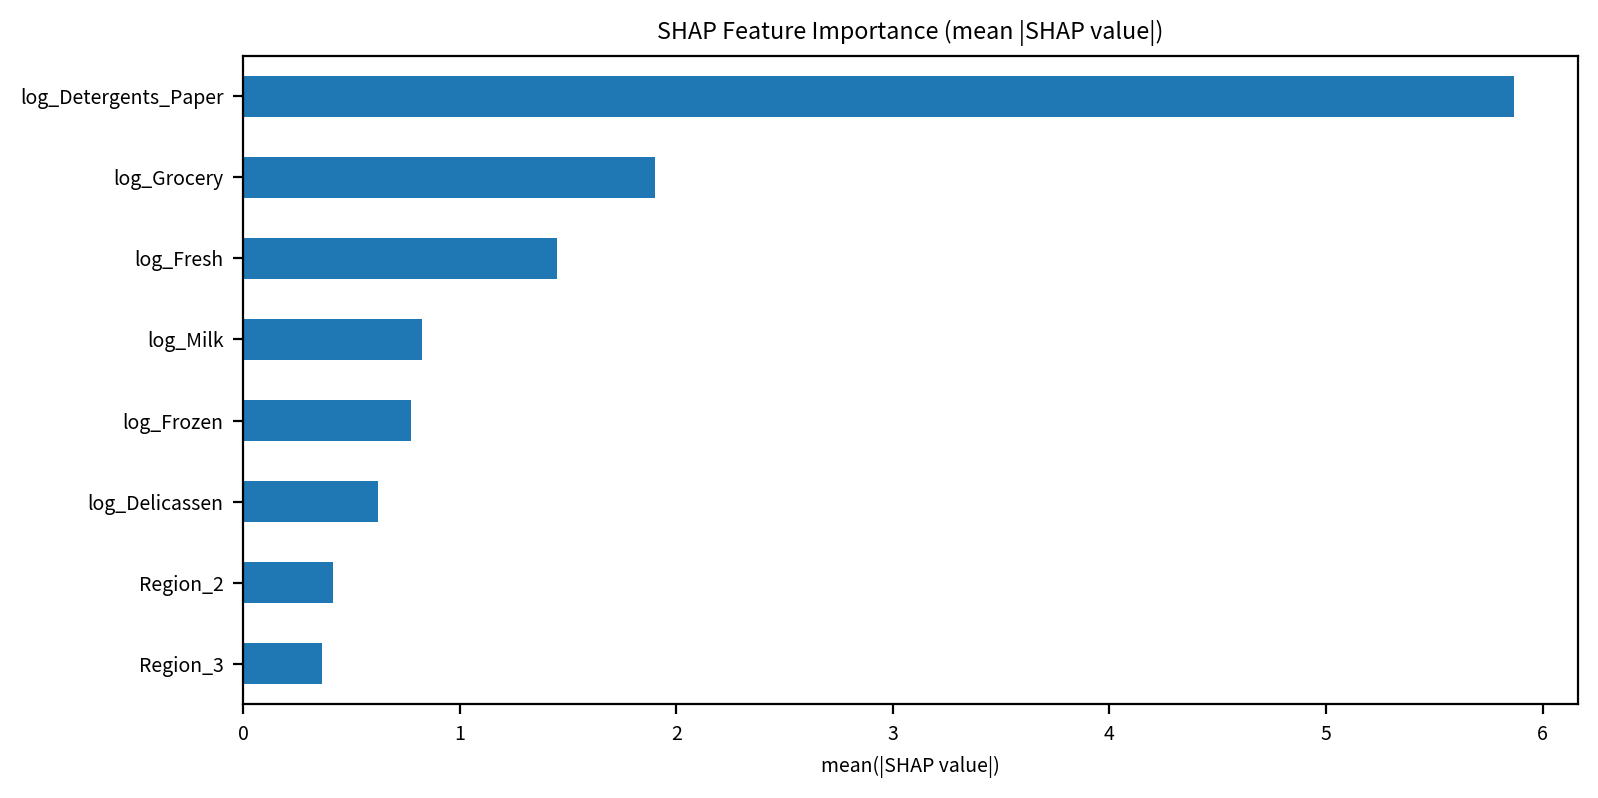

저장 완료: C:\Users\bohee\Documents\GitHub\Machine_learning\[LAB 05] 비지도 학습 - 구매 패턴 기반 고객 군집 분석과 페르소나 도출\blog_figures


In [16]:
# 블로그용 그림 저장 (실행 시 blog_figures/ 에 저장)
out_dir = LAB05_DIR / "blog_figures"
out_dir.mkdir(exist_ok=True)

# 1. 상품별 박스 플롯
fig, ax = plt.subplots(figsize=(10, 4))
df[RAW_COLS].boxplot(ax=ax)
ax.set_ylabel('연간 구매액')
ax.set_title('상품 카테고리별 구매액 분포')
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(out_dir / "fig1_상품별_구매액_박스플롯.png", dpi=150, bbox_inches='tight')
plt.show()

# 2. 지역/채널 파이
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
region_counts = df['Region'].map({1: 'Lisbon', 2: 'Oporto', 3: 'Other Region'}).value_counts()
channel_counts = df['Channel'].map({1: 'Hotel/Restaurant/Cafe', 2: 'Retail'}).value_counts()
ax1.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('주문 지역')
ax2.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%', startangle=90)
ax2.set_title('주문 채널')
plt.tight_layout()
plt.savefig(out_dir / "fig2_지역_채널_파이차트.png", dpi=150, bbox_inches='tight')
plt.show()

# 3. PCA 군집 산점도
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df_plot, x='PC1', y='PC2', hue='ClusterID', palette='Set2', alpha=0.7, ax=ax)
ax.set_title('PCA 기반 K-means 군집 (PC1 vs PC2)')
ax.legend(title='Cluster')
plt.tight_layout()
plt.savefig(out_dir / "fig3_PCA_군집_산점도.png", dpi=150, bbox_inches='tight')
plt.show()

# 4. ROC 곡선
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Channel 예측')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / "fig4_ROC_곡선.png", dpi=150, bbox_inches='tight')
plt.show()

# 5. Feature Importance
fig, ax = plt.subplots(figsize=(8, 4))
fi.plot(kind='barh', ax=ax)
ax.set_title('Logistic Regression - Feature Importance (|coefficient|)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(out_dir / "fig5_Feature_Importance.png", dpi=150, bbox_inches='tight')
plt.show()

# 6. SHAP 중요도
fig, ax = plt.subplots(figsize=(8, 4))
shap_imp_series.plot(kind='barh', ax=ax)
ax.set_title('SHAP Feature Importance (mean |SHAP value|)')
ax.set_xlabel('mean(|SHAP value|)')
plt.tight_layout()
plt.savefig(out_dir / "fig6_SHAP_Importance.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"저장 완료: {out_dir}")

## 4. TabPy 연동 및 태블로 대시보드 제작

- 위에서 사용한 **군집 파이프라인**(scaler → PCA → K-means)과 **채널 분류 모델**은 `save_wholesale_cluster_model.py` 및 각 모델 노트북에서 pkl로 저장됩니다.
- **TabPy** 서버에 `tabpy_wholesale_cluster.py`를 배포하면, Tableau 계산 필드에서 `get_cluster`, `get_pca_coords`, `get_channel`, `get_channel_proba` 등을 호출할 수 있습니다.
- 대시보드에서는 **Select ML Model** 매개변수로 LogisticRegression / XGBoost / SGDClassifier / RandomForest 중 하나를 선택해 채널 예측 결과를 비교할 수 있습니다.

자세한 연동 방법은 `태블로_Select_ML_Model_연동_참고.md`를 참고하세요.

## 5. 결과 해석 및 비즈니스 제언

아래 셀 실행 시 **블로그 포스팅**에 그대로 넣을 수 있는 **지표 요약**과 **비즈니스 제언** 문장이 출력됩니다.  
`블로그_포스팅_초안.md`의 [수치: ...] 자리에 아래 값을 대입하면 됩니다.

In [17]:
# 블로그 인용용 요약 (블로그_포스팅_초안.md [수치] 대입용)
print("=== 비즈니스 KPI ===")
print(f"연간 전체 구매금액 합계: {총_구매금액:,.0f}")
print(f"총 거래 고객 수: {고객수}")
print(f"고객당 평균 연간 구매액: {고객당_평균_구매액:,.0f}")
print("\n=== PCA·K-means ===")
print(f"PCA 주성분 수: {n_components}, 설명 분산: {pca.explained_variance_ratio_.round(3).tolist()}")
print(f"군집 수: 5, 실루엣 스코어: {silhouette_score(pca_scores, clusters):.4f}")
print("\n=== Logistic Regression 채널 예측 ===")
print(f"Accuracy: {acc:.4f}, Precision: {pr:.4f}, Recall: {re:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
print("\n--- 비즈니스 제언 (블로그 5장 요약) ---")
print("• 군집별 '신선식품 위주', '가공식품·세제 위주' 등 페르소나로 타겟 마케팅·재고 정책 활용.")
print("• Milk, Grocery 구매가 채널(호레카 vs 소매) 구분에 가장 중요 → 채널별 맞춤 메시지 설계 참고.")
print("• TabPy로 대시보드에서 모델 전환(Logistic Regression ↔ XGBoost 등) 가능.")

=== 비즈니스 KPI ===
연간 전체 구매금액 합계: 14,619,500
총 거래 고객 수: 440
고객당 평균 연간 구매액: 33,226

=== PCA·K-means ===
PCA 주성분 수: 3, 설명 분산: [0.441, 0.272, 0.107]
군집 수: 5, 실루엣 스코어: 0.2689

=== Logistic Regression 채널 예측 ===
Accuracy: 0.9091, Precision: 0.9032, Recall: 0.8000, F1: 0.8485, AUC: 0.9512

--- 비즈니스 제언 (블로그 5장 요약) ---
• 군집별 '신선식품 위주', '가공식품·세제 위주' 등 페르소나로 타겟 마케팅·재고 정책 활용.
• Milk, Grocery 구매가 채널(호레카 vs 소매) 구분에 가장 중요 → 채널별 맞춤 메시지 설계 참고.
• TabPy로 대시보드에서 모델 전환(Logistic Regression ↔ XGBoost 등) 가능.
